# Zápočtový úkol 1 – Beer Rating Dataset (vícerozměrná Lineární a logistická regrese)

**Vypracoval:** Bc. Pavel Ardolf  
**Předmět:** KSU - Strojové učení

Tato práce bude pracovat s datasetem recenzí piv, na jehož základě se vytvoří model vícerozměrné lineární regrese a logistické regrese.  

Součástí projektu je také:
- **Práce s daty a vizualizace** – základní statistiky, histogramy, scatterploty, korelační matice a heatmapa korelační matice.
- **Příprava dat** – čištění, odstranění chybějících hodnot, filtrování nesmyslných údajů, kontrola rozsahů hodnot, výběr relevantních atributů.
- **Analýza vztahů mezi proměnnými** – výběr vhodných atributů pro regresní model s využitím korelačních koeficientů.
- **Trénink vícerozměrného lineárního modelu** a výpočet metrik (MAE, MSE, RMSE, R²).
- **Interpretace koeficientů regresního modelu**, které vyjadřují vliv jednotlivých senzorických parametrů (aroma, palate, taste…) na celkové hodnocení.
- **Vizualizace výsledků** – graf „skutečné vs. predikované“ hodnocení piva.
- **Klasifikace pomocí logistické regrese** – rozdělení piv na „dobrá“ a „špatná“ na základě odvozené binární proměnné.
- **Teoretické doplnění klasifikace** – sigmoidová funkce, hypotéza logistické regrese, cost function a dělící linie (decision boundary)
- **Závěrečné zhodnocení**, slabiny modelu a možnosti dalšího rozšíření (např. sentiment z textových recenzí, pokročilé modely, doporučovací systém).
  
Cílem je:
- predikovat **celkové hodnocení piva** (`review/overall`) na základě dílčích senzorických hodnocení a obsahu alkoholu,
- demonstrovat použití **vícerozměrné lineární regrese** (regresní úloha),
- a **logistické regrese** (klasifikační úloha „dobré“ vs „špatné“ pivo).

### Vlastnosti datasetu (využité v projektu):

- `beer/ABV` – obsah alkoholu v %  
- `review/aroma` – hodnocení aroma  
- `review/appearance` – hodnocení vzhledu  
- `review/palate` – hodnocení dojmu v ústech  
- `review/taste` – hodnocení chuti  
- `review/overall` – celkové hodnocení (cílová proměnná pro regresi)  
- z `review/overall` bude odvozena binární proměnná `target_good` (klasifikace)

In [1]:
# nacteni zakladnich knihoven (pandas a matplotlib – pro vizualizaci, seaborn – pro heatmapu)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# nacteni datasetu
df = pd.read_csv('beer_reviews.csv', on_bad_lines='skip')

# ukazka nekolika prvnich radku
df.head()

,index,beer/ABV,beer/beerId,beer/brewerId,beer/name,beer/style,review/appearance,review/aroma,review/overall,review/palate,review/taste,review/text,review/timeStruct,review/timeUnix,user/ageInSeconds,user/birthdayRaw,user/birthdayUnix,user/gender,user/profileName
0,40163,5.0,46634,14338,Chiostro,Herbed / Spiced Beer,4.0,4.0,4.0,4.0,4.0,Pours a clouded gold with a thin white head. N...,"{'min': 38, 'hour': 3, 'mday': 16, 'sec': 10, ...",1229398690,NaN,NaN,NaN,NaN,RblWthACoz
1,8135,11.0,3003,395,Bearded Pat's Barleywine,American Barleywine,4.0,3.5,3.5,3.5,3.0,12oz bottle into 8oz snifter.\t\tDeep ruby red...,"{'min': 38, 'hour': 23, 'mday': 8, 'sec': 58, ...",1218238738,NaN,NaN,NaN,NaN,BeerSox
2,10529,4.7,961,365,Naughty Nellie's Ale,American Pale Ale (APA),3.5,4.0,3.5,3.5,3.5,First enjoyed at the brewpub about 2 years ago...,"{'min': 7, 'hour': 18, 'mday': 26, 'sec': 2, '...",1101492422,NaN,NaN,NaN,Male,mschofield
3,44610,4.4,429,1,Pilsner Urquell,Czech Pilsener,3.0,3.0,2.5,3.0,3.0,First thing I noticed after pouring from green...,"{'min': 7, 'hour': 1, 'mday': 20, 'sec': 5, 'y...",1308532025,1.209827e+09,"Aug 10, 1976",208508400.0,Male,molegar76
4,37062,4.4,4904,1417,Black Sheep Ale (Special),English Pale Ale,4.0,3.0,3.0,3.5,2.5,A: pours an amber with a one finger head but o...,"{'min': 51, 'hour': 6, 'mday': 12, 'sec': 48, ...",1299912708,NaN,NaN,NaN,NaN,Brewbro000


Základní informace o datech:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37500 entries, 0 to 37499
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              37500 non-null  int64  
 1   beer/ABV           37500 non-null  float64
 2   beer/beerId        37500 non-null  int64  
 3   beer/brewerId      37500 non-null  int64  
 4   beer/name          37500 non-null  object 
 5   beer/style         37500 non-null  object 
 6   review/appearance  37500 non-null  float64
 7   review/aroma       37500 non-null  float64
 8   review/overall     37500 non-null  float64
 9   review/palate      37500 non-null  float64
 10  review/taste       37500 non-null  float64
 11  review/text        37490 non-null  object 
 12  review/timeStruct  37500 non-null  object 
 13  review/timeUnix    37500 non-null  int64  
 14  user/ageInSeconds  7856 non-null   float64
 15  user/birthdayRaw   7856 non-null   object

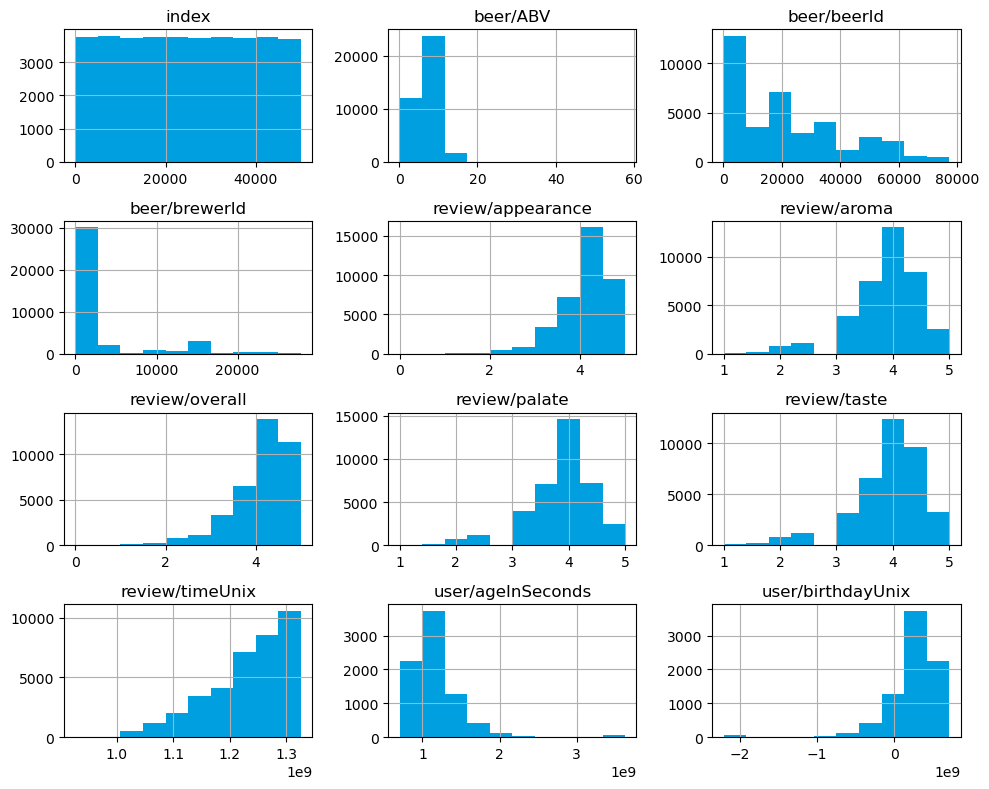


Korelační matice:
                      index  beer/ABV  beer/beerId  beer/brewerId  \
index              1.000000 -0.149483    -0.306118      -0.339801   
beer/ABV          -0.149483  1.000000     0.330658       0.007455   
beer/beerId       -0.306118  0.330658     1.000000       0.523657   
beer/brewerId     -0.339801  0.007455     0.523657       1.000000   
review/appearance  0.054229  0.288376    -0.007204      -0.077973   
review/aroma       0.040257  0.386340     0.045427      -0.081571   
review/overall     0.054493  0.197005    -0.021981      -0.084932   
review/palate      0.039838  0.350656     0.027752      -0.066468   
review/taste       0.047179  0.354033     0.019321      -0.100513   
review/timeUnix   -0.155089  0.248846     0.424539       0.206507   
user/ageInSeconds  0.022322 -0.079039    -0.049398      -0.001398   
user/birthdayUnix -0.022322  0.079039     0.049398       0.001398   

                   review/appearance  review/aroma  review/overall  \
index        

In [2]:
# -------------------------- #
# PRÁCE S DATY A VIZUALIZACE #
# -------------------------- #

print("Základní informace o datech:")
print(df.info())

print("\nZákladní statistiky:")
print(df.describe())

print("\nPohled na data:")
print(df.head())

print("\nPočet prázdných polí v každém sloupci:")
print(df.isnull().sum())

numeric_df = df.select_dtypes(include=[np.number])
print("\nSumy a průměry pro číselné sloupce:")
print("Suma:")
print(numeric_df.sum())
print("Průměr:")
print(numeric_df.mean())

print("\nGrafické zobrazení dat:")

numeric_df.hist(figsize=(10, 8), color='#009fdf')
plt.tight_layout()
plt.show()

corr_matrix = numeric_df.corr()
print("\nKorelační matice:")
print(corr_matrix)


In [3]:
# ---------------------- #
# ČIŠTĚNÍ A PŘÍPRAVA DAT #
# ---------------------- #

print("Počet chybějících hodnot před čištěním:")
print(df.isnull().sum())

# odstraneni radku, kde chybi celkove hodnoceni
df = df[df['review/overall'].notna()]

# odstraneni radku, kde chybi dilci hodnoceni - nutne pro regresi
df = df[
    df['review/aroma'].notna() &
    df['review/appearance'].notna() &
    df['review/palate'].notna() &
    df['review/taste'].notna()
]

# odstraneni radku, kde je ABV nesmysl
df = df[(df['beer/ABV'] > 0) & (df['beer/ABV'] < 20)]

print("\nPočet chybějících hodnot po čištění:")
print(df.isnull().sum())

print("\nNový tvar datasetu (po čištění):")
print(df.shape)


Počet chybějících hodnot před čištěním:
index                    0
beer/ABV                 0
beer/beerId              0
beer/brewerId            0
beer/name                0
beer/style               0
review/appearance        0
review/aroma             0
review/overall           0
review/palate            0
review/taste             0
review/text             10
review/timeStruct        0
review/timeUnix          0
user/ageInSeconds    29644
user/birthdayRaw     29644
user/birthdayUnix    29644
user/gender          22186
user/profileName         5
dtype: int64

Počet chybějících hodnot po čištění:
index                    0
beer/ABV                 0
beer/beerId              0
beer/brewerId            0
beer/name                0
beer/style               0
review/appearance        0
review/aroma             0
review/overall           0
review/palate            0
review/taste             0
review/text             10
review/timeStruct        0
review/timeUnix          0
user/ageInSeconds 

Korelační koeficienty pro použité proměnné:
beer/ABV             0.201041
review/aroma         0.616124
review/appearance    0.498739
review/palate        0.697232
review/taste         0.785271
review/overall       1.000000
Name: review/overall, dtype: float64


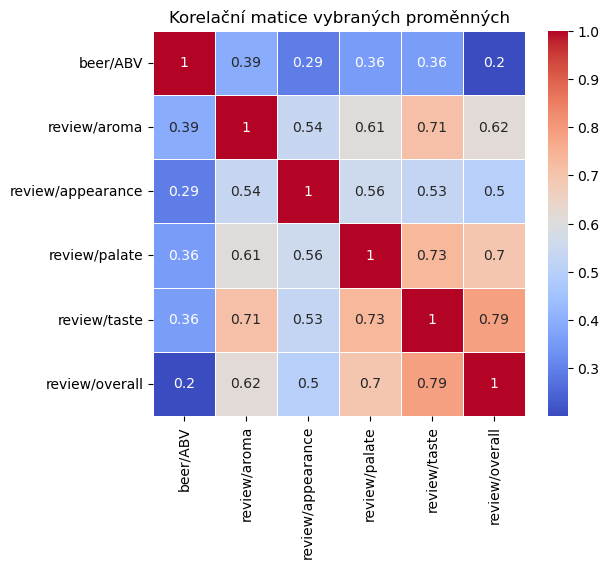

In [4]:
# ------------------------------ #
# ANALÝZA VZTAHŮ MEZI PROMĚNNÝMI #
# ------------------------------ #

feature_cols = [
    'beer/ABV',
    'review/aroma',
    'review/appearance',
    'review/palate',
    'review/taste'
]

corr_features = df[feature_cols + ['review/overall']].corr()
print("Korelační koeficienty pro použité proměnné:")
print(corr_features['review/overall'])

plt.figure(figsize=(6, 5))
sns.heatmap(corr_features, annot=True, cmap='coolwarm', linewidths=.5)
plt.title("Korelační matice vybraných proměnných")
plt.show()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_raw = df[feature_cols]
X_scaled = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_scaled, columns=feature_cols)
y = df['review/overall']

In [5]:
# ----------------------------------------- #
# TRÉNINK VÍCEROZMĚRNNÉHO LINEÁRNÍHO MODELU #
# ----------------------------------------- #

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# rozdeleni na trenovaci a testovaci mnozinu (napr 80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# metriky
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error):  {mse:.4f}")
print(f"RMSE (Root MSE):            {rmse:.4f}")
print(f"R²   (koeficient determinace): {r2:.4f}")

coef_df = pd.DataFrame({
    'Vlastnost': feature_cols,
    'Koeficient': model.coef_
})
coef_df


MAE  (Mean Absolute Error): 0.3058
MSE  (Mean Squared Error):  0.1633
RMSE (Root MSE):            0.4041
R²   (koeficient determinace): 0.6663


,Vlastnost,Koeficient
0,beer/ABV,-0.099317
1,review/aroma,0.062565
2,review/appearance,0.038937
3,review/palate,0.174228
4,review/taste,0.393266


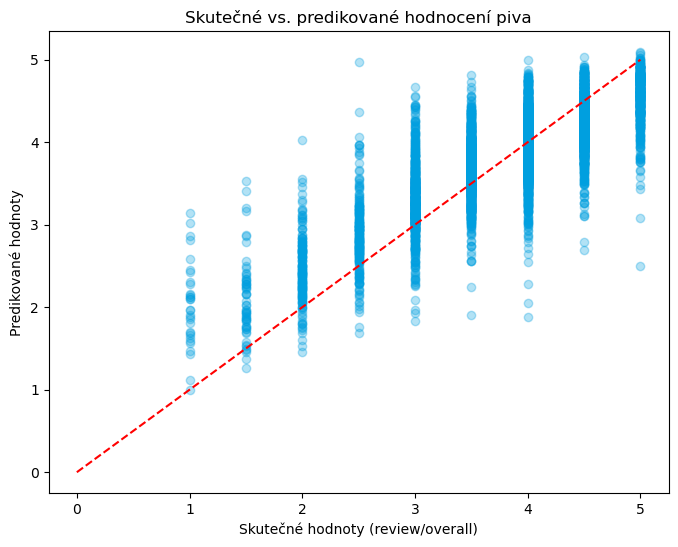

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="#009fdf")
plt.xlabel("Skutečné hodnoty (review/overall)")
plt.ylabel("Predikované hodnoty")
plt.title("Skutečné vs. predikované hodnocení piva")
plt.plot([0, 5], [0, 5], '--', color='red')
plt.show()

## Interpretace výsledků modelu a vyhodnocení modelu

Vícerozměrná lineární regrese byla použita k predikci celkového hodnocení piva (`review/overall`) na základě pěti vstupních proměnných: `beer/ABV`, `review/aroma`, `review/appearance`, `review/palate` a `review/taste`.

### Kvalita modelu
- **R² = 0.6663**  
  Model vysvětluje přibližně 66,63 % variability v celkovém hodnocení. To je velmi dobrý výsledek vzhledem k tomu, že se jedná o subjektivní lidská hodnocení.

- **RMSE = 0.4041**  
  Průměrná chyba predikce je přibližně 0,4 bodu na pětibodové škále, což je akceptovatelné.

- **MAE = 0.3058**  
  Průměrná absolutní chyba ukazuje, že se model většinou netrefí o více než cca 0,4 bodu.

### Význam vstupních proměnných (koeficienty)
- Největší vliv má **hodnocení chuti (`review/taste`)**, což odpovídá realitě.
- Druhým nejdůležitějším parametrem je **`review/palate`**.
- `review/aroma` a `review/appearance` mají mírný pozitivní vliv.
- `beer/ABV` má **negativní** koeficient, což může souviset s tím, že silnější piva nebývají hodnocena vyšším počtem běžných uživatelů.

### Závěr
Model dokáže poměrně přesně předpovídat celkové hodnocení piva na základě dílčích parametrů. Výsledky jsou konzistentní a odpovídají očekávání. Model lze dále vylepšit přidáním dalších proměnných nebo analýzou textových recenzí.


In [7]:
# -------------------------------- #
# KLASIFIKACE - LOGISTICKÁ REGRESE #
# -------------------------------- #

# cilova promenna review/overall
df['target_good'] = (df['review/overall'] >= 4).astype(int)

features = [
    'beer/ABV',
    'review/aroma',
    'review/appearance',
    'review/palate',
    'review/taste'
]

X = df[features]
y = df['target_good']

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

target_names = ['Špatné pivo (0)', 'Dobré pivo (1)']

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Skutečné: špatné', 'Skutečné: dobré'],
    columns=['Predikce: špatné', 'Predikce: dobré']
)

print("Matrice záměn (Confusion Matrix):")
display(cm_df)

print("\nKlasifikační zpráva (Classification Report):")
print(classification_report(y_test, y_pred, target_names=target_names))


Matrice záměn (Confusion Matrix):


,Predikce: špatné,Predikce: dobré
Skutečné: špatné,1634,753
Skutečné: dobré,407,4705



Klasifikační zpráva (Classification Report):
                 precision    recall  f1-score   support

Špatné pivo (0)       0.80      0.68      0.74      2387
 Dobré pivo (1)       0.86      0.92      0.89      5112

       accuracy                           0.85      7499
      macro avg       0.83      0.80      0.81      7499
   weighted avg       0.84      0.85      0.84      7499



## Vyhodnocení klasifikace

Model logistické regrese predikuje pravděpodobnost, že pivo bude mít celkové hodnocení ≥ 4.  
Prahová hodnota je 0.5, takže pokud je predikovaná pravděpodobnost ≥ 0.5, model zařadí pivo do třídy **„dobré“**, jinak do třídy **„špatné“**.

### Confusion matrix

Matrice záměn pro tento model:

|                       | **Predikce: špatné** | **Predikce: dobré** |
|-----------------------|-----------------------|----------------------|
| **Skutečné: špatné (0)** | 1634 (TN)              | 753 (FP)             |
| **Skutečné: dobré (1)**  | 407 (FN)               | 4705 (TP)            |

Interpretace:

- **TP (True Positive)** – model správně označil dobré pivo jako dobré  
- **TN (True Negative)** – model správně označil špatné pivo jako špatné  
- **FP (False Positive)** – model označil špatné pivo jako dobré  
- **FN (False Negative)** – model označil dobré pivo jako špatné

Podle matice můžeme počítat tyto metriky:

- **accuracy = (TP + TN) / celkem**  
- **precision = TP / (TP + FP)**  
- **recall (sensitivity) = TP / (TP + FN)**  
- **specificity = TN / (TN + FP)**  

### Metriky (podle classification_report)

- **Špatné pivo (třída 0):**  
  - precision = **0.80**  
  - recall = **0.68**  
  - f1-score = **0.74**

- **Dobré pivo (třída 1):**  
  - precision = **0.86**  
  - recall = **0.93**  
  - f1-score = **0.89**

- **Celková přesnost (accuracy): 0.85**

Model je tedy celkově přesný na úrovni **85 %**.

### Shrnutí
- Logistická regrese modeluje pravděpodobnost (0–1), takže je pro klasifikaci vhodnější než lineární regrese.  
- Model má velmi dobrou přesnost **(≈ 85 %)**, zejména u třídy **„dobré pivo“**, kterých je v datech více.  
- U špatných piv je recall nižší (≈ 0.69), což znamená, že model část špatných piv označí jako dobré.


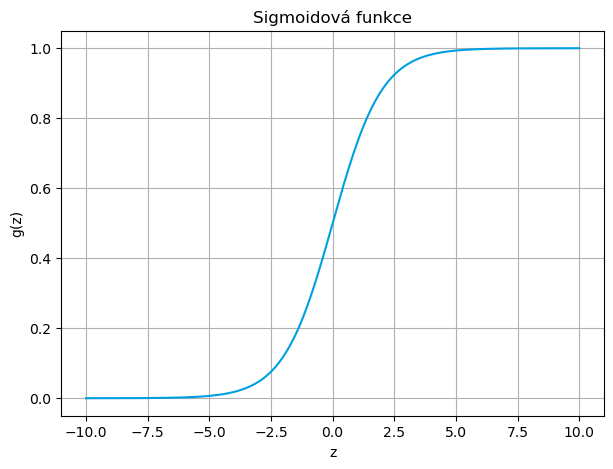

In [8]:
# ----------------------------- #
# VIZUALIZACE SIGMOIDOVÉ FUNKCE #
# ----------------------------- #

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# vizualizace sigmoidove funkce
z = np.linspace(-10, 10, 200)
s = sigmoid(z)

plt.figure(figsize=(7,5))
plt.plot(z, s, color="#009fdf")
plt.title("Sigmoidová funkce")
plt.xlabel("z")
plt.ylabel("g(z)")
plt.grid(True)
plt.show()


In [9]:
# -------------------------- #
# IMPLEMENTACE COST FUNCTION #
# -------------------------- #

def logistic_cost(theta, X, y):
    m = len(y)
    z = X.dot(theta)
    h = sigmoid(z)
    epsilon = 1e-10  # prevence deleni nulou
    cost = -(1/m) * np.sum(
        y * np.log(h + epsilon) +
        (1 - y) * np.log(1 - h + epsilon)
    )
    return cost

# vypocitani cost pro nahodne parametry theta
np.random.seed(0)
theta_test = np.random.randn(len(features))

X_sample = X_train.values
y_sample = y_train.values

print("Cost function (náhodné theta):", logistic_cost(theta_test, X_sample, y_sample))

Cost function (náhodné theta): 7.50529934648402


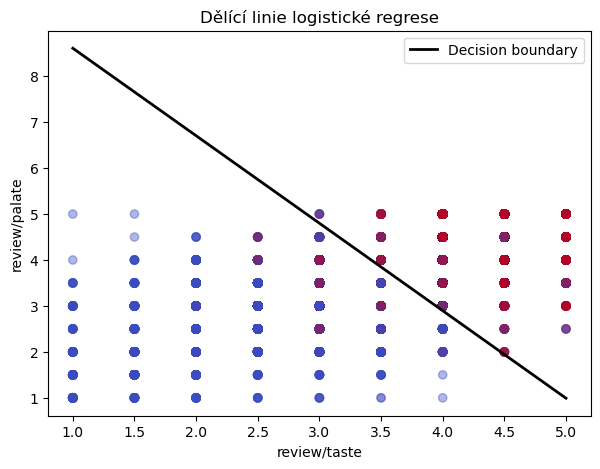

In [10]:
# -------------------------------- #
# DĚLÍCÍ LINIE (DECISION BOUNDARY) #
# -------------------------------- #

from sklearn.linear_model import LogisticRegression

# dve vlastnosti pro vizualizaci - review/taste a review/palate
X_vis = df[['review/taste', 'review/palate']]
y_vis = df['target_good']

clf2 = LogisticRegression()
clf2.fit(X_vis, y_vis)

# koeficienty a bias
w1, w2 = clf2.coef_[0]
b = clf2.intercept_[0]

# vytvoreni decision boundary
x_vals = np.linspace(X_vis['review/taste'].min(), X_vis['review/taste'].max(), 200)
y_vals = -(w1 * x_vals + b) / w2

# scatter plot + boundary
plt.figure(figsize=(7,5))
plt.scatter(X_vis['review/taste'], X_vis['review/palate'], c=y_vis, cmap='coolwarm', alpha=0.4)
plt.plot(x_vals, y_vals, color='black', linewidth=2, label="Decision boundary")
plt.xlabel("review/taste")
plt.ylabel("review/palate")
plt.title("Dělící linie logistické regrese")
plt.legend()
plt.show()

# Závěrečné zhodnocení

Cílem tohoto projektu bylo aplikovat metody strojového učení na reálný dataset recenzí piv. Nejprve byla provedena příprava dat, odstranění chybějících hodnot a filtr nesmyslných záznamů, což je nezbytný krok pro správnou funkci regresních i klasifikačních modelů.

Na očištěném datasetu byla vytvořena vícerozměrná lineární regrese, která dosáhla koeficientu determinace **R² ≈ 0,67**, což znamená, že model vysvětlil přibližně dvě třetiny variability celkového hodnocení piva. Mezi nejsilnější prediktory patřila zejména proměnná *review/taste* (chuť) a *review/palate* (dojem v ústech).

Dále byla vytvořena logistická regrese, která rozdělila piva na „dobrá“ a „špatná“ na základě celkového hodnocení. Klasifikátor dosáhl vysoké přesnosti, což souvisí s tím, že většina piv v datasetu má převážně kladná hodnocení. Metriky jako precision, recall i konfuzní matice ukázaly, že model je použitelný a realistický.

Součástí projektu bylo také teoretické doplnění logistické regrese - sigmoidová funkce, hypotéza, chybová funkce a dělící linie.
